In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import statsmodels.api as sm
import sklearn.metrics as metrics
import warnings
warnings.filterwarnings('ignore')

| Approach | Fits | Strength | Weakness |
|---|---|---|---|
| **Prophet** | one series at a time | handles holidays/seasonality with very little tuning | one model *per* station×crime pair — slow at scale, no cross-series learning |
| **ARIMA / SARIMA** | one series at a time | classical, interpretable, well-understood confidence intervals | same one-model-per-series cost; needs a reasonably long, regular series to fit well |
| **LightGBM (supervised)** | one model for *all* series at once | learns shared patterns across stations/crime types, cheap to retrain, handles hundreds of series in one shot | needs the lag/seasonal feature engineering already done for us |

In [3]:
df = pd.read_csv("../dataset/training_data/timeseries_counts_supervised.csv",parse_dates=['period'])
df = df.sort_values(["PoliceStationID","CrimeMinorHeadID","period"]).reset_index(drop=True)

print(f"{len(df)} rows | "
      f"{df['PoliceStationID'].nunique()} stations x "
      f"{df['CrimeMinorHeadID'].nunique()} crime types x "
      f"{df['period'].nunique()} months")
df.head()

552636 rows | 129 stations x 63 crime types x 68 months


,PoliceStationID,CrimeMinorHeadID,period,case_count,heinous_count,resolution_rate,month,month_sin,month_cos,count_lag_1,count_lag_3,count_lag_12,rolling_mean_3
0,73,1,2020-12-01,0,0,0.0,12,-2.449294e-16,1.000000e+00,NaN,NaN,NaN,NaN
1,73,1,2021-01-01,0,0,0.0,1,5.000000e-01,8.660254e-01,0.0,NaN,NaN,NaN
2,73,1,2021-02-01,0,0,0.0,2,8.660254e-01,5.000000e-01,0.0,NaN,NaN,NaN
3,73,1,2021-03-01,0,0,0.0,3,1.000000e+00,6.123234e-17,0.0,0.0,NaN,0.0
4,73,1,2021-04-01,0,0,0.0,4,8.660254e-01,-5.000000e-01,0.0,0.0,NaN,0.0


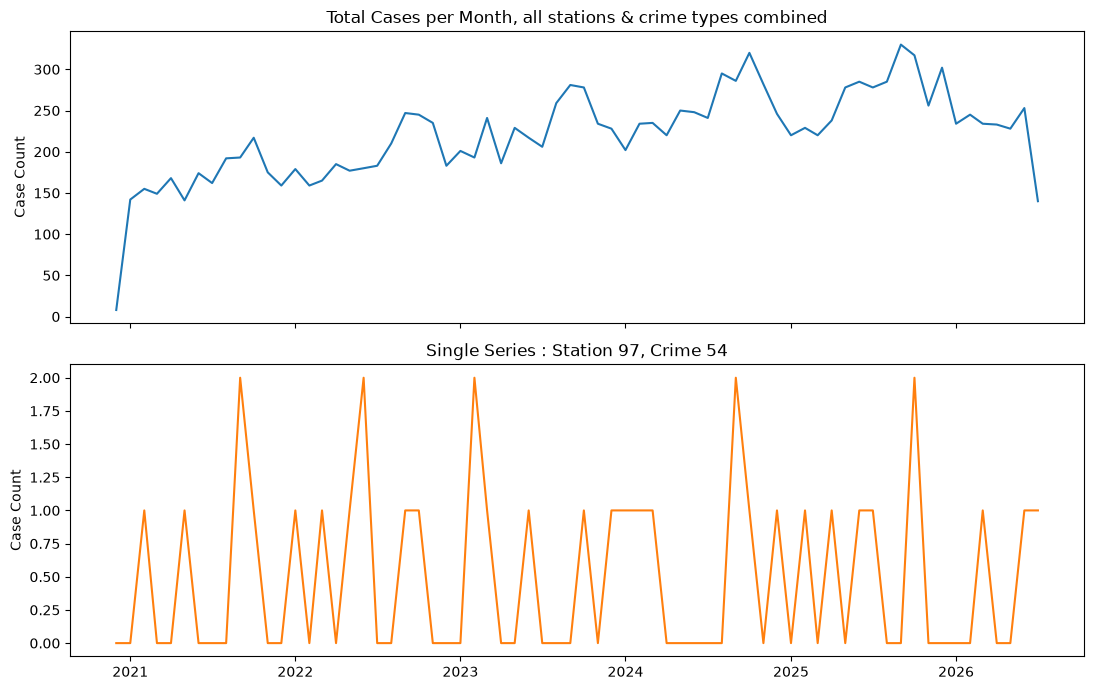

In [5]:
# Let's take a quick check

fig, axes = plt.subplots(2,1, figsize=(11,7), sharex=True)

total_by_month = df.groupby("period")["case_count"].sum()
axes[0].plot(total_by_month.index, total_by_month.values, color="tab:blue")
axes[0].set_title("Total Cases per Month, all stations & crime types combined")
axes[0].set_ylabel("Case Count")

busiest_key = (df.groupby(["PoliceStationID","CrimeMinorHeadID"])["case_count"]
               .sum().sort_values(ascending=False).index[0])

st_id, cr_id = busiest_key

example = df[(df["PoliceStationID"]==st_id) & (df["CrimeMinorHeadID"]==cr_id)]
axes[1].plot(example["period"], example["case_count"], color="tab:orange")
axes[1].set_title(f"Single Series : Station {st_id}, Crime {cr_id}")
axes[1].set_ylabel("Case Count")

plt.tight_layout()
plt.show()

*Never split a time series randomly*. 

Let's hold out the last 6 months of every station X crime series at the test set.

In [6]:
N_TEST_MONTHS = 6
cutoff = df["period"].max() - pd.DateOffset(months=N_TEST_MONTHS)

train = df[df["period"] <= cutoff].copy()
test = df[df["period"] > cutoff].copy()

print(f"Cutoff: {cutoff.date()} | ")
print(f"Train rows: {len(train)} | Test rows: {len(test)}")

Cutoff: 2026-01-01 | 
Train rows: 503874 | Test rows: 48762


- **Training rows with no `count_lag_12` yet** (the first 12 months of each series, before
  any 12-month-back value exists) are dropped from *training* — a model can't learn from
  a feature that's always missing. We keep them in scope for `test` though; LightGBM
  handles missing values at prediction time by learning a default split direction for them.
- **Test categories must match train's categories.** If a station only appears in the test
  window (shouldn't happen here, but worth guarding against in real data), LightGBM would
  otherwise error on an unseen category.

In [7]:
FEATURES = ["PoliceStationID", "CrimeMinorHeadID", "month_sin","month_cos",
            "count_lag_1","count_lag_3","count_lag_12", "rolling_mean_3"]

TARGET = "case_count"

CAT_FEATURES = ["PoliceStationID", "CrimeMinorHeadID"]

train_fit = train.dropna(subset = ["count_lag_12"]).copy()

for c in CAT_FEATURES:
    train_fit[c] = train_fit[c].astype("category")
    test[c] = pd.Categorical(test[c], categories = train_fit[c].cat.categories)

n_dropped = len(train) - len(train_fit)
print(f"Dropped {n_dropped} rows from training set due to missing lag features"
      f"({n_dropped / len(train):.1%} of train)")

X_train, y_train = train_fit[FEATURES], train_fit[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

Dropped 97524 rows from training set due to missing lag features(19.4% of train)


## FITTING THE MODEL

`case_count` is a count: non-negative integers, often small, sometimes zero. 

In [11]:
model = lgb.LGBMRegressor(
    objective="poisson",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state = 42,
    verbosity = -1,
)

model.fit(X_train, y_train, categorical_feature=CAT_FEATURES)

print("Model fitted")

Model fitted
